In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 7.11

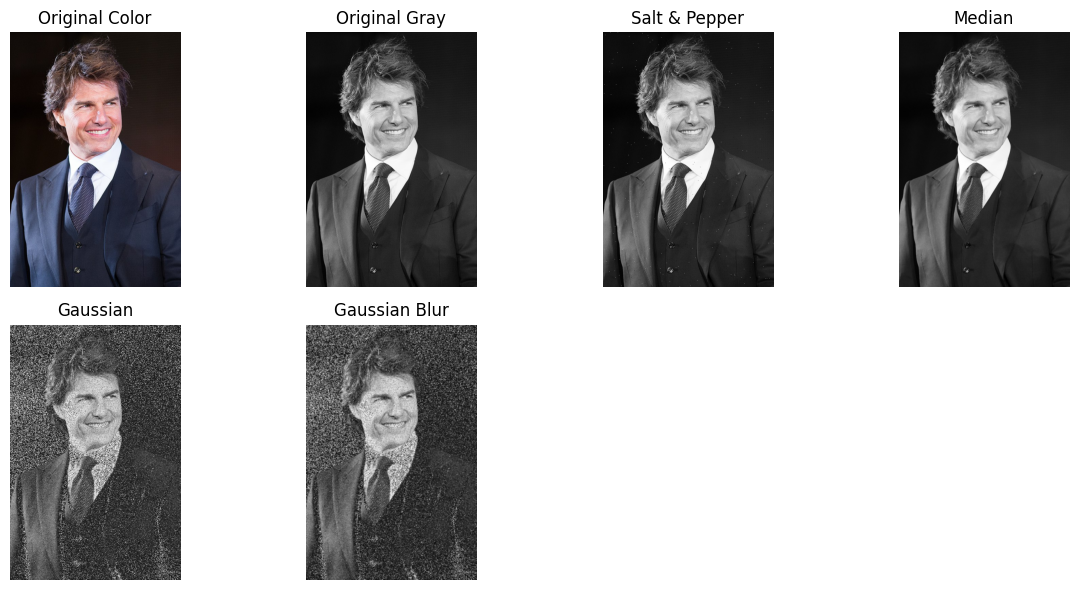

In [10]:
tom = cv2.imread("TC_JR.jpg", 0)
tom_orignal = cv2.imread("TC_JR.jpg")

# Add salt-and-pepper noise
noisy_sp = tom.copy()
num_pixels = 500
for i in range(num_pixels):
    y = np.random.randint(0, tom.shape[0])
    x = np.random.randint(0, tom.shape[1])
    noisy_sp[y, x] = 255 if np.random.rand() > 0.5 else 0

# Add Gaussian noise
noisy_gauss = tom + np.random.normal(0, 25, tom.shape).astype(np.uint8)

# Remove noise
median = cv2.medianBlur(noisy_sp, 3)
gauss_blur = cv2.GaussianBlur(noisy_gauss, (3, 3), 0)

plt.figure(figsize=(12, 6))
plt.subplot(241), plt.title("Original Color"), plt.imshow(cv2.cvtColor(tom_orignal, cv2.COLOR_BGR2RGB)), plt.axis("off")
plt.subplot(242), plt.title("Original Gray"), plt.imshow(tom, cmap="gray"), plt.axis("off")
plt.subplot(243), plt.title("Salt & Pepper"), plt.imshow(noisy_sp, cmap="gray"), plt.axis("off")
plt.subplot(244), plt.title("Median"), plt.imshow(median, cmap="gray"), plt.axis("off")
plt.subplot(245), plt.title("Gaussian"), plt.imshow(noisy_gauss, cmap="gray"), plt.axis("off")
plt.subplot(246), plt.title("Gaussian Blur"), plt.imshow(gauss_blur, cmap="gray"), plt.axis("off")
plt.tight_layout()
plt.show()

### 7.12

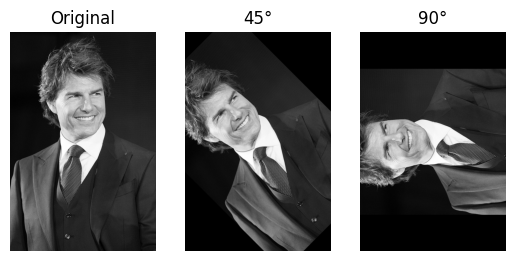

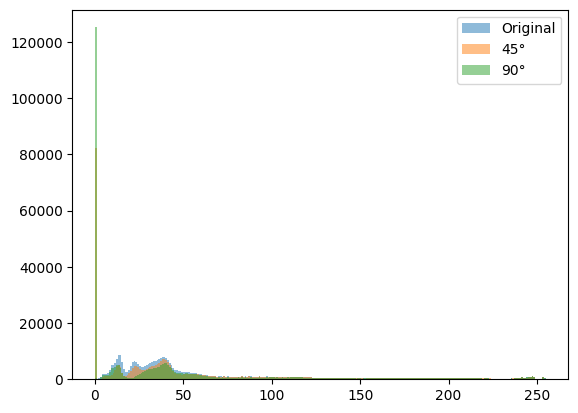

In [11]:
# Rotate image by 45° and 90°
h, w = tom.shape
center = (w // 2, h // 2)
M45 = cv2.getRotationMatrix2D(center, 45, 1)
rot45 = cv2.warpAffine(tom, M45, (w, h))
M90 = cv2.getRotationMatrix2D(center, 90, 1)
rot90 = cv2.warpAffine(tom, M90, (w, h))

plt.subplot(131), plt.title("Original"), plt.imshow(tom, cmap="gray"), plt.axis("off")
plt.subplot(132), plt.title("45°"), plt.imshow(rot45, cmap="gray"), plt.axis("off")
plt.subplot(133), plt.title("90°"), plt.imshow(rot90, cmap="gray"), plt.axis("off")
plt.show()

plt.hist(tom.ravel(), bins=256, alpha=0.5, label="Original")
plt.hist(rot45.ravel(), bins=256, alpha=0.5, label="45°")
plt.hist(rot90.ravel(), bins=256, alpha=0.5, label="90°")
plt.legend()
plt.show()

### 7.13

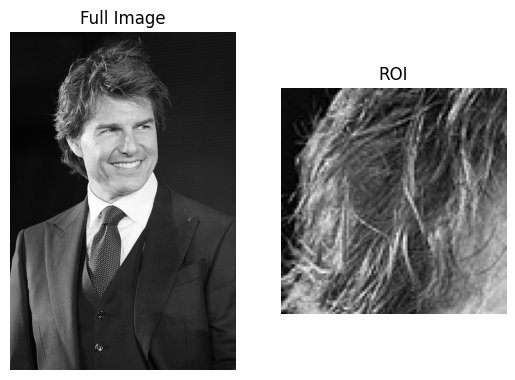

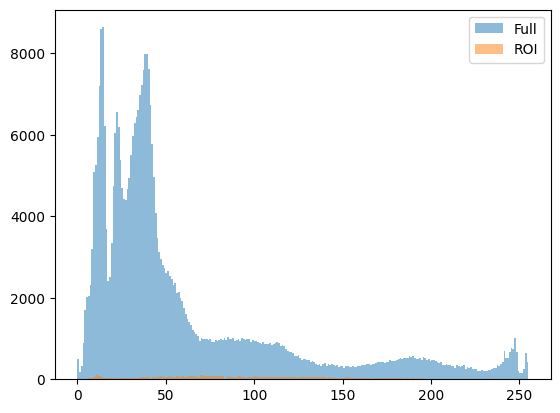

In [12]:
# Crop ROI and compare histograms
roi = tom[100:200, 100:200]
plt.subplot(121), plt.title("Full Image"), plt.imshow(tom, cmap="gray"), plt.axis(
    "off"
)
plt.subplot(122), plt.title("ROI"), plt.imshow(roi, cmap="gray"), plt.axis("off")
plt.show()
plt.hist(tom.ravel(), bins=256, alpha=0.5, label="Full")
plt.hist(roi.ravel(), bins=256, alpha=0.5, label="ROI")
plt.legend()
plt.show()

### 7.14 

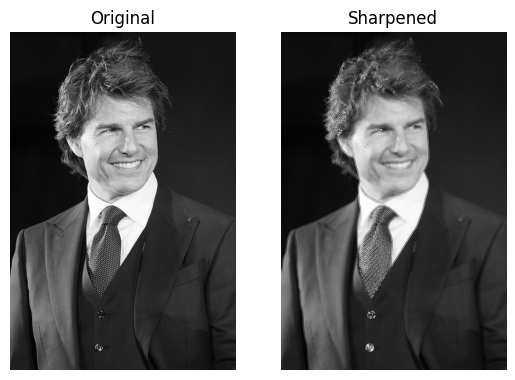

In [13]:
# Image sharpening using Laplacian filter
lap = cv2.Laplacian(tom, cv2.CV_64F)
sharp = cv2.convertScaleAbs(tom + lap)
plt.subplot(121), plt.title("Original"), plt.imshow(tom, cmap="gray"), plt.axis("off")
plt.subplot(122), plt.title("Sharpened"), plt.imshow(sharp, cmap="gray"), plt.axis(
    "off"
)
plt.show()

### 7.15

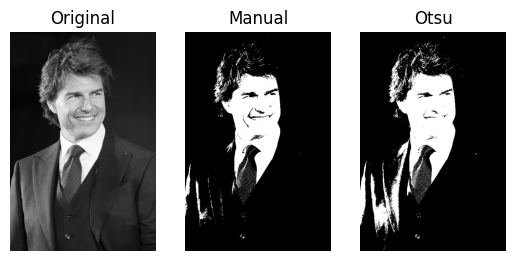

In [14]:
# Otsu's thresholding vs manual thresholding
_, manual = cv2.threshold(tom, 127, 255, cv2.THRESH_BINARY)
_, otsu = cv2.threshold(tom, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.subplot(131), plt.title("Original"), plt.imshow(tom, cmap="gray"), plt.axis("off")
plt.subplot(132), plt.title("Manual"), plt.imshow(manual, cmap="gray"), plt.axis("off")
plt.subplot(133), plt.title("Otsu"), plt.imshow(otsu, cmap="gray"), plt.axis("off")
plt.show()

### 7.16 

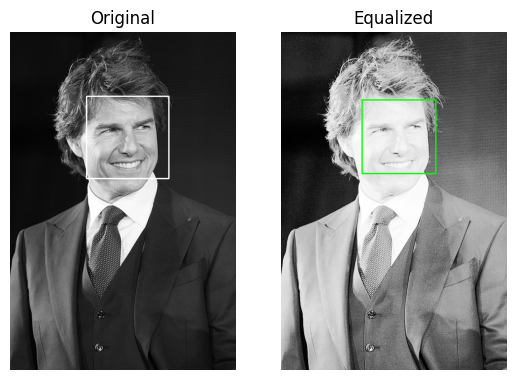

In [15]:
# Face detection using Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
img = tom.copy()
faces = face_cascade.detectMultiScale(img, 1.3, 5)
for x, y, w, h in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
# Equalize and detect again
img_eq = cv2.equalizeHist(tom)
faces_eq = face_cascade.detectMultiScale(img_eq, 1.3, 5)
img_eq_color = cv2.cvtColor(img_eq, cv2.COLOR_GRAY2BGR)
for x, y, w, h in faces_eq:
    cv2.rectangle(img_eq_color, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.subplot(121), plt.title("Original"), plt.imshow(img, cmap="gray"), plt.axis("off")
plt.subplot(122), plt.title("Equalized"), plt.imshow(img_eq_color), plt.axis("off")
plt.show()

### 7.17 

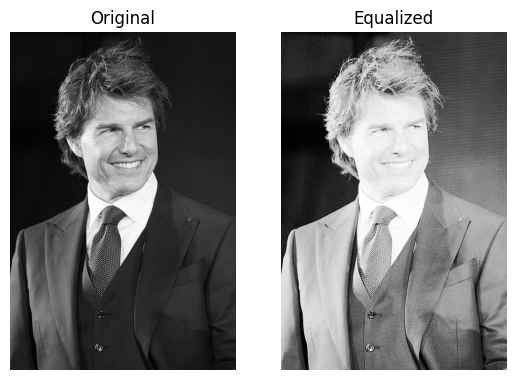

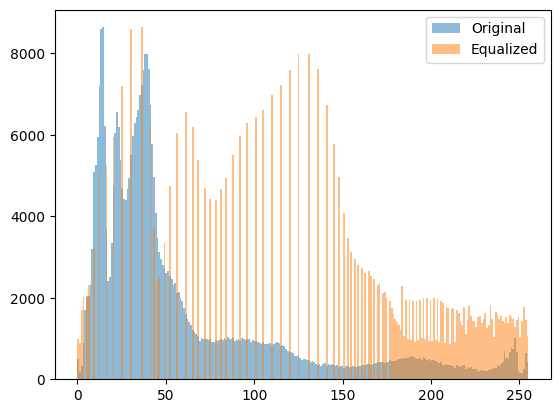

In [16]:
# Histogram equalization
img_eq = cv2.equalizeHist(tom)
plt.subplot(121), plt.title("Original"), plt.imshow(tom, cmap="gray"), plt.axis("off")
plt.subplot(122), plt.title("Equalized"), plt.imshow(img_eq, cmap="gray"), plt.axis(
    "off"
)
plt.show()
plt.hist(tom.ravel(), bins=256, alpha=0.5, label="Original")
plt.hist(img_eq.ravel(), bins=256, alpha=0.5, label="Equalized")
plt.legend()
plt.show()